In [127]:
pip install pandas


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [128]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [129]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [130]:
import pandas as pd
import sklearn
import matplotlib

In [131]:
df = pd.read_csv("RTA Dataset.csv")
df

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


In [132]:
columns_to_remove = [
    "Casualty_class",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Casualty_severity",
    "Work_of_casuality",
    "Fitness_of_casuality"
]

## These columns were removed because they mostly concern about the post casuality information and
## for this project, we are concerned with accident severity and not post casuality information

df = df.drop(columns=columns_to_remove)
df

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Going straight,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Other,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Other,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


In [133]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["Accident_severity"].value_counts())

Dataset shape: (12316, 26)

Columns:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']

Target distribution:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


In [134]:
# Convert Time column into Hour feature
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df["Hour"] = df["Time"].dt.hour

# Drop original Time column
df = df.drop(columns=["Time"])

print("Dataset shape after Time conversion:", df.shape)
print("\nHour missing values:", df["Hour"].isnull().sum())
print("\nHour value counts:")
print(df["Hour"].value_counts().sort_index())

Dataset shape after Time conversion: (12316, 26)

Hour missing values: 0

Hour value counts:
Hour
0      206
1      134
2       84
3       84
4       91
5       76
6      214
7      532
8      828
9      559
10     500
11     603
12     691
13     772
14     639
15     874
16     921
17    1228
18     956
19     708
20     604
21     401
22     402
23     209
Name: count, dtype: int64


/var/folders/wm/y6_w1__j26s7v72lsmzxrwtw0000gn/T/ipykernel_1922/2818965541.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"], errors="coerce")


In [135]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [136]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64


In [137]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Accident_severity"])
y = df["Accident_severity"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

X_train: (8621, 25)
X_val: (1847, 25)
X_test: (1848, 25)

Training target distribution:
Accident_severity
Slight Injury     7290
Serious Injury    1220
Fatal injury       111
Name: count, dtype: int64

Validation target distribution:
Accident_severity
Slight Injury     1562
Serious Injury     261
Fatal injury        24
Name: count, dtype: int64

Test target distribution:
Accident_severity
Slight Injury     1563
Serious Injury     262
Fatal injury        23
Name: count, dtype: int64


In [138]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", len(cat_cols))
print(cat_cols)

print("\nNumerical columns:", len(num_cols))
print(num_cols)

Categorical columns: 22
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Pedestrian_movement', 'Cause_of_accident']

Numerical columns: 3
['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour']


In [139]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, cat_cols),
        ("num", numerical_pipeline, num_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight=None,
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

y_val_pred_lr = log_reg_model.predict(X_val)

print("Logistic Regression Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("Macro Precision:", precision_score(y_val, y_val_pred_lr, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_lr, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_lr, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_lr, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr, zero_division=0))

Logistic Regression Validation Results
Accuracy: 0.8456957227937195
Macro Precision: 0.44881533731235307
Macro Recall: 0.33546080850597604
Macro F1: 0.3104646330313357
Weighted F1: 0.7770436028888914

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        24
Serious Injury       0.50      0.01      0.02       261
 Slight Injury       0.85      1.00      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.45      0.34      0.31      1847
  weighted avg       0.79      0.85      0.78      1847



In [141]:
def high_severity_recall(y_true, y_pred):
    high_classes = ["Serious Injury", "Fatal injury"]

    y_true_high = y_true.isin(high_classes)
    y_pred_high = pd.Series(y_pred, index=y_true.index).isin(high_classes)

    true_high_count = y_true_high.sum()
    correctly_detected_high = (y_true_high & y_pred_high).sum()

    return correctly_detected_high / true_high_count


lr_high_severity_recall = high_severity_recall(y_val, y_val_pred_lr)

print("Logistic Regression High-Severity Recall:", lr_high_severity_recall)

Logistic Regression High-Severity Recall: 0.007017543859649123


In [142]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    ))
])

rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)

print("Random Forest Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Macro Precision:", precision_score(y_val, y_val_pred_rf, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_rf, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_rf, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_rf, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_val, y_val_pred_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf, zero_division=0))

Random Forest Validation Results
Accuracy: 0.8478613968597726
Macro Precision: 0.61584373304395
Macro Recall: 0.33844189016602805
Macro F1: 0.3158876605805373
Weighted F1: 0.7801700626866728
High-Severity Recall: 0.014035087719298246

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        24
Serious Injury       1.00      0.02      0.03       261
 Slight Injury       0.85      1.00      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.62      0.34      0.32      1847
  weighted avg       0.86      0.85      0.78      1847



In [143]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    ))
])

et_model.fit(X_train, y_train)

y_val_pred_et = et_model.predict(X_val)

print("Extra Trees Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_et))
print("Macro Precision:", precision_score(y_val, y_val_pred_et, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_et, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_et, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_et, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_val, y_val_pred_et))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_et, zero_division=0))

Extra Trees Validation Results
Accuracy: 0.8462371413102329
Macro Precision: 0.5043986502771752
Macro Recall: 0.33567421012782844
Macro F1: 0.31058974952104723
Weighted F1: 0.7773207607165709
High-Severity Recall: 0.007017543859649123

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        24
Serious Injury       0.67      0.01      0.02       261
 Slight Injury       0.85      1.00      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.50      0.34      0.31      1847
  weighted avg       0.81      0.85      0.78      1847



In [144]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(X_val)

print("Gradient Boosting Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_gb))
print("Macro Precision:", precision_score(y_val, y_val_pred_gb, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_gb, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_gb, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_gb, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_val, y_val_pred_gb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_gb, zero_division=0))

Gradient Boosting Validation Results
Accuracy: 0.8494856524093124
Macro Precision: 0.8327812262138315
Macro Recall: 0.3602037454028712
Macro F1: 0.35914995753323614
Weighted F1: 0.7888358778929998
High-Severity Recall: 0.0456140350877193

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       1.00      0.04      0.08        24
Serious Injury       0.65      0.04      0.08       261
 Slight Injury       0.85      1.00      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.83      0.36      0.36      1847
  weighted avg       0.82      0.85      0.79      1847



In [145]:
pip install catboost


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [146]:
from catboost import CatBoostClassifier

cat_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="MultiClass",
        random_seed=42,
        verbose=0
    ))
])

cat_model.fit(X_train, y_train)

y_val_pred_cat = cat_model.predict(X_val).ravel()

print("CatBoost Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_cat))
print("Macro Precision:", precision_score(y_val, y_val_pred_cat, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_cat, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_cat, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_cat, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_val, y_val_pred_cat))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_cat, zero_division=0))

CatBoost Validation Results
Accuracy: 0.8462371413102329
Macro Precision: 0.4729037267080745
Macro Recall: 0.3378016853004711
Macro F1: 0.3154568135220429
Weighted F1: 0.7793150012283545
High-Severity Recall: 0.014035087719298246

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        24
Serious Injury       0.57      0.02      0.03       261
 Slight Injury       0.85      1.00      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.47      0.34      0.32      1847
  weighted avg       0.80      0.85      0.78      1847



In [147]:
validation_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_val, y_val_pred_lr),
        "Macro Precision": precision_score(y_val, y_val_pred_lr, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_val, y_val_pred_lr, average="macro", zero_division=0),
        "Macro F1": f1_score(y_val, y_val_pred_lr, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_val, y_val_pred_lr, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_val, y_val_pred_lr)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_val, y_val_pred_rf),
        "Macro Precision": precision_score(y_val, y_val_pred_rf, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_val, y_val_pred_rf, average="macro", zero_division=0),
        "Macro F1": f1_score(y_val, y_val_pred_rf, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_val, y_val_pred_rf, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_val, y_val_pred_rf)
    },
    {
        "Model": "Extra Trees",
        "Accuracy": accuracy_score(y_val, y_val_pred_et),
        "Macro Precision": precision_score(y_val, y_val_pred_et, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_val, y_val_pred_et, average="macro", zero_division=0),
        "Macro F1": f1_score(y_val, y_val_pred_et, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_val, y_val_pred_et, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_val, y_val_pred_et)
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": accuracy_score(y_val, y_val_pred_gb),
        "Macro Precision": precision_score(y_val, y_val_pred_gb, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_val, y_val_pred_gb, average="macro", zero_division=0),
        "Macro F1": f1_score(y_val, y_val_pred_gb, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_val, y_val_pred_gb, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_val, y_val_pred_gb)
    },
    {
        "Model": "CatBoost",
        "Accuracy": accuracy_score(y_val, y_val_pred_cat),
        "Macro Precision": precision_score(y_val, y_val_pred_cat, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_val, y_val_pred_cat, average="macro", zero_division=0),
        "Macro F1": f1_score(y_val, y_val_pred_cat, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_val, y_val_pred_cat, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_val, y_val_pred_cat)
}
])

validation_results = validation_results.round(4)

print(validation_results)

                 Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  Logistic Regression    0.8457           0.4488        0.3355    0.3105   
1        Random Forest    0.8479           0.6158        0.3384    0.3159   
2          Extra Trees    0.8462           0.5044        0.3357    0.3106   
3    Gradient Boosting    0.8495           0.8328        0.3602    0.3591   
4             CatBoost    0.8462           0.4729        0.3378    0.3155   

   Weighted F1  High-Severity Recall  
0       0.7770                0.0070  
1       0.7802                0.0140  
2       0.7773                0.0070  
3       0.7888                0.0456  
4       0.7793                0.0140  


In [148]:
alpha = 0.4
beta = 0.6

validation_results["Risk-Sensitive Score"] = (
    alpha * validation_results["Macro F1"] +
    beta * validation_results["High-Severity Recall"]
)

validation_results["Ensemble Weight"] = (
    validation_results["Risk-Sensitive Score"] /
    validation_results["Risk-Sensitive Score"].sum()
)

validation_results = validation_results.round(4)

print(validation_results[[
    "Model",
    "Macro F1",
    "High-Severity Recall",
    "Risk-Sensitive Score",
    "Ensemble Weight"
]])

                 Model  Macro F1  High-Severity Recall  Risk-Sensitive Score  \
0  Logistic Regression    0.3105                0.0070                0.1284   
1        Random Forest    0.3159                0.0140                0.1348   
2          Extra Trees    0.3106                0.0070                0.1284   
3    Gradient Boosting    0.3591                0.0456                0.1710   
4             CatBoost    0.3155                0.0140                0.1346   

   Ensemble Weight  
0           0.1842  
1           0.1933  
2           0.1842  
3           0.2453  
4           0.1931  


In [149]:
models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "Gradient Boosting": gb_model,
    "CatBoost": cat_model
}

weights = dict(zip(
    validation_results["Model"],
    validation_results["Ensemble Weight"]
))

classes = log_reg_model.named_steps["classifier"].classes_
print("Class order:", classes)

weighted_probs = np.zeros((len(X_val), len(classes)))

for model_name, model in models.items():
    probs = model.predict_proba(X_val)
    weighted_probs += weights[model_name] * probs

print("Weighted validation probabilities created successfully.")

print("Risk-Sensitive Ensemble Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_ensemble))
print("Macro Precision:", precision_score(y_val, y_val_pred_ensemble, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_ensemble, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_ensemble, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_ensemble, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_val, y_val_pred_ensemble))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_ensemble, zero_division=0))

Class order: ['Fatal injury' 'Serious Injury' 'Slight Injury']
Weighted validation probabilities created successfully.
Risk-Sensitive Ensemble Validation Results
Accuracy: 0.8467785598267461
Macro Precision: 0.6155374887082204
Macro Recall: 0.33588761174968074
Macro F1: 0.3107149486835238
Weighted F1: 0.7775978220290451
High-Severity Recall: 0.007017543859649123

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        24
Serious Injury       1.00      0.01      0.02       261
 Slight Injury       0.85      1.00      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.62      0.34      0.31      1847
  weighted avg       0.86      0.85      0.78      1847



In [150]:
class_risk_weights = {
    "Fatal injury": 3.0,
    "Serious Injury": 2.0,
    "Slight Injury": 1.0
}

adjusted_probs = weighted_probs.copy()

for i, cls in enumerate(classes):
    adjusted_probs[:, i] = adjusted_probs[:, i] * class_risk_weights[cls]

y_val_pred_risk_adjusted = classes[np.argmax(adjusted_probs, axis=1)]

print("Risk-Adjusted Ensemble Validation Results")
print("Accuracy:", accuracy_score(y_val, y_val_pred_risk_adjusted))
print("Macro Precision:", precision_score(y_val, y_val_pred_risk_adjusted, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_val, y_val_pred_risk_adjusted, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_val, y_val_pred_risk_adjusted, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_val, y_val_pred_risk_adjusted, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_val, y_val_pred_risk_adjusted))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_risk_adjusted, zero_division=0))

Risk-Adjusted Ensemble Validation Results
Accuracy: 0.8494856524093124
Macro Precision: 0.6899967775543812
Macro Recall: 0.38026165818783597
Macro F1: 0.3943683409436834
Weighted F1: 0.7951661572498027
High-Severity Recall: 0.07719298245614035

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.67      0.08      0.15        24
Serious Injury       0.55      0.07      0.12       261
 Slight Injury       0.85      0.99      0.92      1562

      accuracy                           0.85      1847
     macro avg       0.69      0.38      0.39      1847
  weighted avg       0.81      0.85      0.80      1847



In [151]:
risk_settings = [
    {"Fatal injury": 2.0, "Serious Injury": 1.5, "Slight Injury": 1.0},
    {"Fatal injury": 3.0, "Serious Injury": 2.0, "Slight Injury": 1.0},
    {"Fatal injury": 4.0, "Serious Injury": 2.5, "Slight Injury": 1.0},
    {"Fatal injury": 5.0, "Serious Injury": 3.0, "Slight Injury": 1.0},
]

risk_tuning_results = []

for setting in risk_settings:
    adjusted_probs = weighted_probs.copy()

    for i, cls in enumerate(classes):
        adjusted_probs[:, i] = adjusted_probs[:, i] * setting[cls]

    y_pred = classes[np.argmax(adjusted_probs, axis=1)]

    risk_tuning_results.append({
        "Fatal Weight": setting["Fatal injury"],
        "Serious Weight": setting["Serious Injury"],
        "Slight Weight": setting["Slight Injury"],
        "Accuracy": accuracy_score(y_val, y_pred),
        "Macro F1": f1_score(y_val, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_val, y_pred)
    })

risk_tuning_results = pd.DataFrame(risk_tuning_results).round(4)

print(risk_tuning_results)

   Fatal Weight  Serious Weight  Slight Weight  Accuracy  Macro F1  \
0           2.0             1.5            1.0    0.8473    0.3296   
1           3.0             2.0            1.0    0.8495    0.3944   
2           4.0             2.5            1.0    0.8370    0.4000   
3           5.0             3.0            1.0    0.8257    0.4169   

   Weighted F1  High-Severity Recall  
0       0.7857                0.0386  
1       0.7952                0.0772  
2       0.7927                0.1018  
3       0.7954                0.1649  


In [152]:
final_class_risk_weights = {
    "Fatal injury": 5.0,
    "Serious Injury": 3.0,
    "Slight Injury": 1.0
}

In [153]:
# Get weighted ensemble probabilities on test set
weighted_test_probs = np.zeros((len(X_test), len(classes)))

for model_name, model in models.items():
    probs = model.predict_proba(X_test)
    weighted_test_probs += weights[model_name] * probs

adjusted_test_probs = weighted_test_probs.copy()

for i, cls in enumerate(classes):
    adjusted_test_probs[:, i] = adjusted_test_probs[:, i] * final_class_risk_weights[cls]

y_test_pred_final = classes[np.argmax(adjusted_test_probs, axis=1)]

print("Final Risk-Sensitive Ensemble Test Results")
print("Accuracy:", accuracy_score(y_test, y_test_pred_final))
print("Macro Precision:", precision_score(y_test, y_test_pred_final, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, y_test_pred_final, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_test, y_test_pred_final, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, y_test_pred_final, average="weighted", zero_division=0))
print("High-Severity Recall:", high_severity_recall(y_test, y_test_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_final, zero_division=0))

Final Risk-Sensitive Ensemble Test Results
Accuracy: 0.8376623376623377
Macro Precision: 0.5170977011494253
Macro Recall: 0.41745080339641466
Macro F1: 0.4387157289353871
Weighted F1: 0.8051274259446037
High-Severity Recall: 0.16842105263157894

Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.25      0.13      0.17        23
Serious Injury       0.44      0.16      0.23       262
 Slight Injury       0.86      0.96      0.91      1563

      accuracy                           0.84      1848
     macro avg       0.52      0.42      0.44      1848
  weighted avg       0.80      0.84      0.81      1848



In [154]:
test_predictions = {
    "Logistic Regression": log_reg_model.predict(X_test),
    "Random Forest": rf_model.predict(X_test),
    "Extra Trees": et_model.predict(X_test),
    "Gradient Boosting": gb_model.predict(X_test),
    "CatBoost": cat_model.predict(X_test).ravel(),
    "Risk-Sensitive Ensemble": y_test_pred_final
}

test_results = []

for model_name, y_pred in test_predictions.items():
    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "High-Severity Recall": high_severity_recall(y_test, y_pred)
    })

test_results = pd.DataFrame(test_results).round(4)
print(test_results)

                     Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0      Logistic Regression    0.8479           0.5604        0.3395    0.3183   
1            Random Forest    0.8485           0.6160        0.3397    0.3184   
2              Extra Trees    0.8485           0.6160        0.3397    0.3184   
3        Gradient Boosting    0.8479           0.4918        0.3448    0.3298   
4                 CatBoost    0.8479           0.6159        0.3384    0.3159   
5  Risk-Sensitive Ensemble    0.8377           0.5171        0.4175    0.4387   

   Weighted F1  High-Severity Recall  
0       0.7813                0.0175  
1       0.7816                0.0175  
2       0.7816                0.0175  
3       0.7862                0.0386  
4       0.7803                0.0140  
5       0.8051                0.1684  


In [155]:
validation_results.to_csv("validation_baseline_results.csv", index=False)
risk_tuning_results.to_csv("risk_tuning_results.csv", index=False)
test_results.to_csv("final_test_results.csv", index=False)

print("All updated result files saved.")

All updated result files saved.


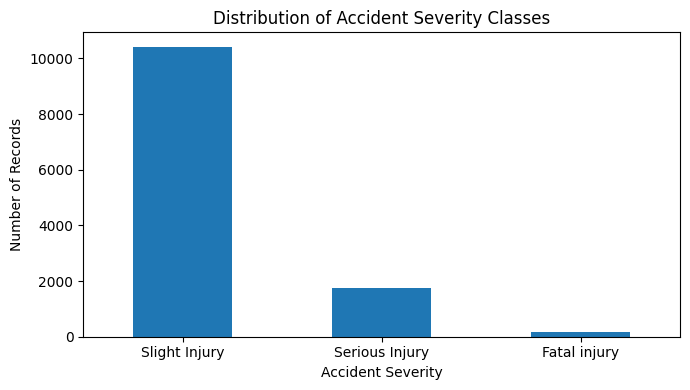

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64
Saved: class_distribution.png


In [156]:
import matplotlib.pyplot as plt

class_counts = df["Accident_severity"].value_counts()

plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")
plt.title("Distribution of Accident Severity Classes")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

print(class_counts)
print("Saved: class_distribution.png")

In [157]:
## explainability

In [158]:
# Get transformed feature names

ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]

cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(cat_feature_names) + num_cols

print("Total transformed features:", len(all_feature_names))

Total transformed features: 176


In [159]:
gb_classifier = gb_model.named_steps["classifier"]

importances = gb_classifier.feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                                     Feature  Importance
173              Number_of_vehicles_involved    0.232769
174                     Number_of_casualties    0.117213
175                                     Hour    0.079568
10               Age_band_of_driver_Under 18    0.028193
110  Light_conditions_Darkness - no lighting    0.023797
2                       Day_of_week_Saturday    0.020440
11                Age_band_of_driver_Unknown    0.017779
111                Light_conditions_Daylight    0.014483
119               Weather_conditions_Unknown    0.014177
92                Types_of_Junction_Crossing    0.013290
71   Area_accident_occured_Residential areas    0.010252
95                   Types_of_Junction_Other    0.009987
37            Type_of_vehicle_Lorry (11?40Q)    0.009430
96                 Types_of_Junction_T Shape    0.008859
20                 Educational_level_Unknown    0.008698
99                 Types_of_Junction_Y Shape    0.008681
46           Type_of_vehicle_Sp

In [160]:
print(importance_df.head(20))

                                     Feature  Importance
173              Number_of_vehicles_involved    0.232769
174                     Number_of_casualties    0.117213
175                                     Hour    0.079568
10               Age_band_of_driver_Under 18    0.028193
110  Light_conditions_Darkness - no lighting    0.023797
2                       Day_of_week_Saturday    0.020440
11                Age_band_of_driver_Unknown    0.017779
111                Light_conditions_Daylight    0.014483
119               Weather_conditions_Unknown    0.014177
92                Types_of_Junction_Crossing    0.013290
71   Area_accident_occured_Residential areas    0.010252
95                   Types_of_Junction_Other    0.009987
37            Type_of_vehicle_Lorry (11?40Q)    0.009430
96                 Types_of_Junction_T Shape    0.008859
20                 Educational_level_Unknown    0.008698
99                 Types_of_Junction_Y Shape    0.008681
46           Type_of_vehicle_Sp

In [161]:
ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]

cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(cat_feature_names) + num_cols

print("Total transformed features:", len(all_feature_names))

Total transformed features: 176


In [163]:
gb_classifier = gb_model.named_steps["classifier"]

importances = gb_classifier.feature_importances_

print("Number of importance values:", len(importances))

Number of importance values: 176


In [164]:
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                                     Feature  Importance
173              Number_of_vehicles_involved    0.232769
174                     Number_of_casualties    0.117213
175                                     Hour    0.079568
10               Age_band_of_driver_Under 18    0.028193
110  Light_conditions_Darkness - no lighting    0.023797
2                       Day_of_week_Saturday    0.020440
11                Age_band_of_driver_Unknown    0.017779
111                Light_conditions_Daylight    0.014483
119               Weather_conditions_Unknown    0.014177
92                Types_of_Junction_Crossing    0.013290


In [165]:
importance_df.to_csv("gradient_boosting_feature_importance.csv", index=False)

print("Saved: gradient_boosting_feature_importance.csv")

Saved: gradient_boosting_feature_importance.csv


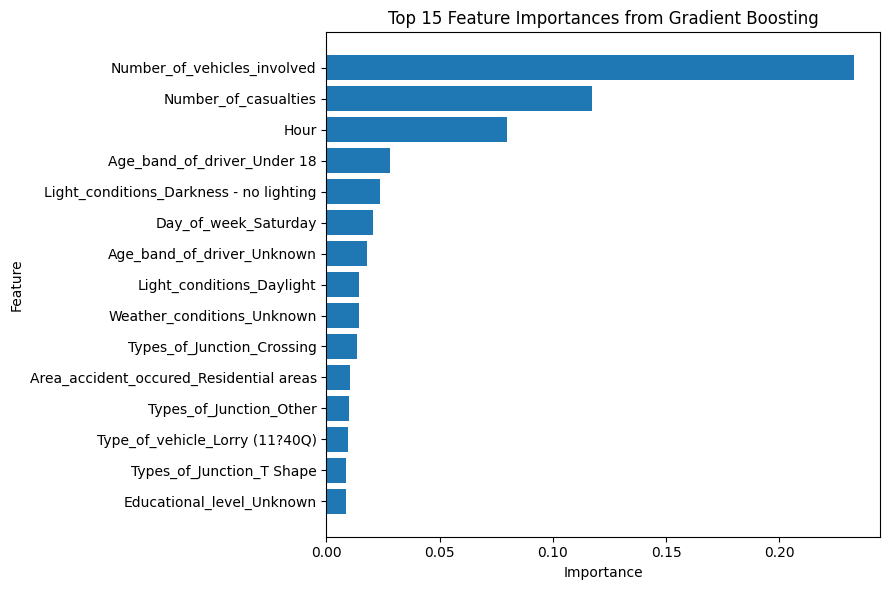

Saved: top_feature_importance.png


In [166]:
top15 = importance_df.head(15).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Top 15 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("top_feature_importance.png", dpi=300)
plt.show()

print("Saved: top_feature_importance.png")

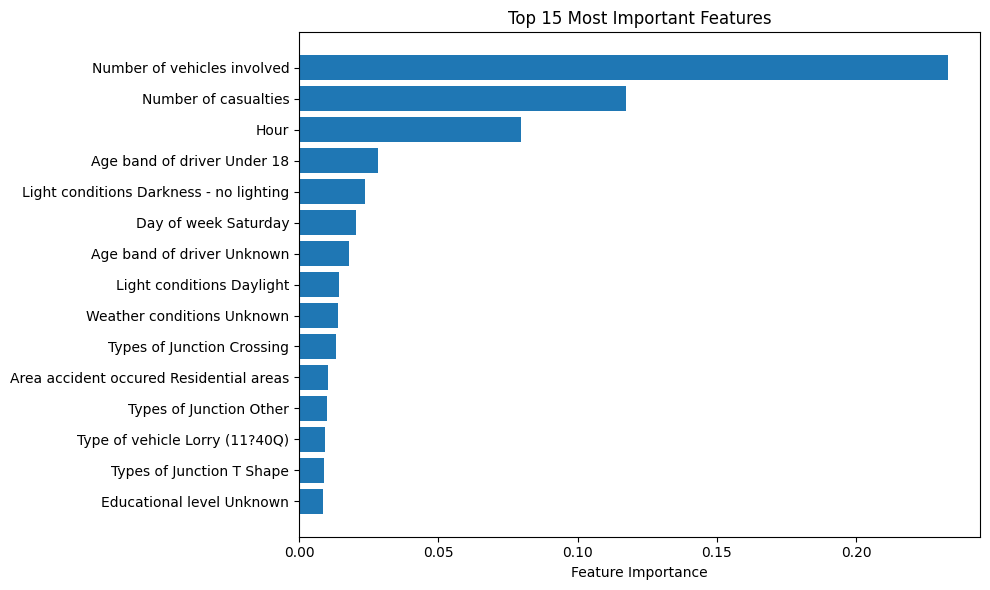

In [167]:
top15 = importance_df.head(15).copy()

top15["Feature"] = (
    top15["Feature"]
    .str.replace("_", " ", regex=False)
)

top15 = top15.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("top_feature_importance_clean.png", dpi=300)
plt.show()

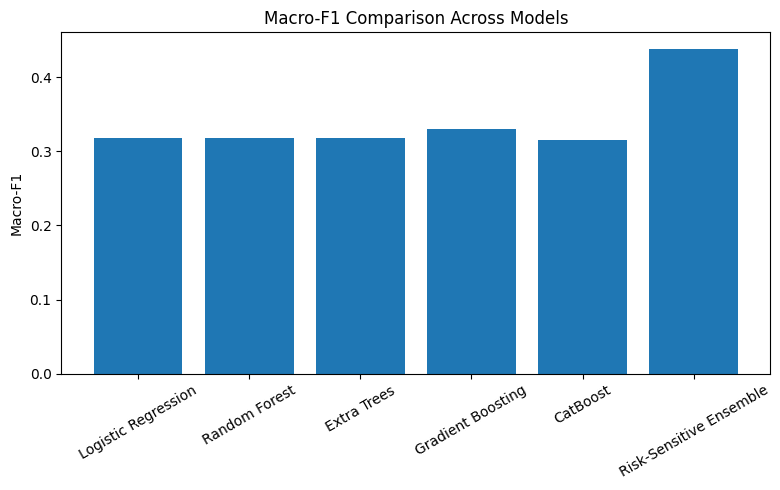

Saved: macro_f1_comparison.png


In [168]:
plt.figure(figsize=(8,5))

plt.bar(
    test_results["Model"],
    test_results["Macro F1"]
)

plt.title("Macro-F1 Comparison Across Models")
plt.ylabel("Macro-F1")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("macro_f1_comparison.png", dpi=300)
plt.show()

print("Saved: macro_f1_comparison.png")

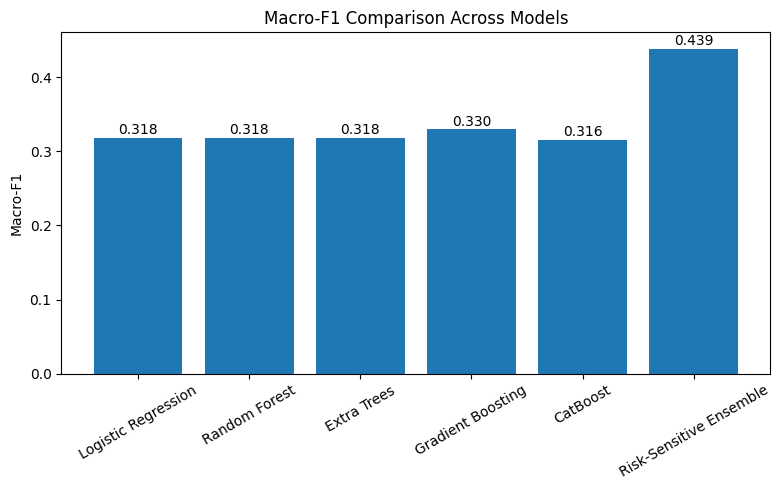

In [169]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    test_results["Model"],
    test_results["Macro F1"]
)

plt.title("Macro-F1 Comparison Across Models")
plt.ylabel("Macro-F1")
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig("macro_f1_comparison.png", dpi=300)
plt.show()

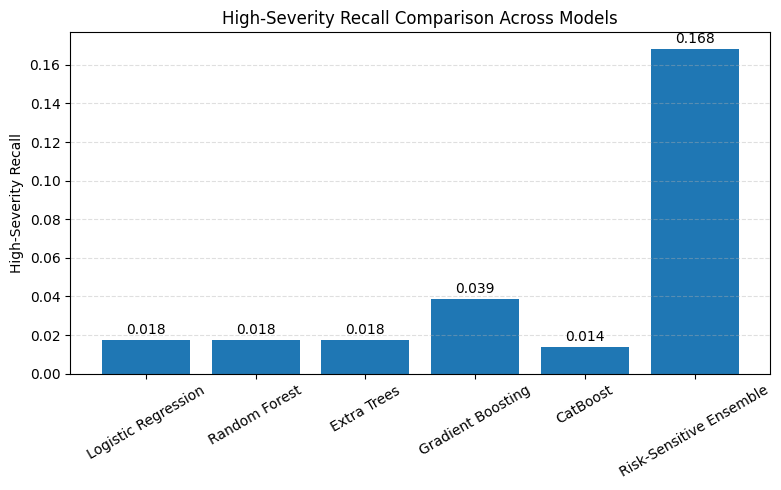

Saved: high_severity_recall_comparison.png


In [170]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    test_results["Model"],
    test_results["High-Severity Recall"]
)

plt.title("High-Severity Recall Comparison Across Models")
plt.ylabel("High-Severity Recall")
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("high_severity_recall_comparison.png", dpi=300)
plt.show()

print("Saved: high_severity_recall_comparison.png")

In [172]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 460 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


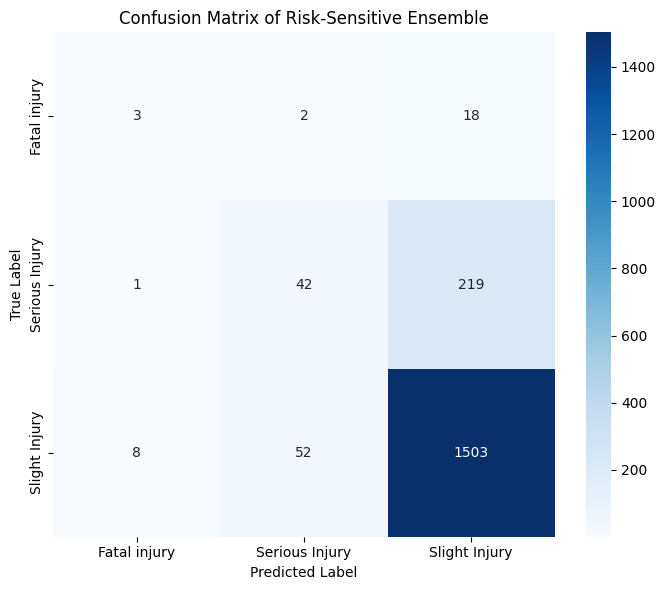

[[   3    2   18]
 [   1   42  219]
 [   8   52 1503]]


In [173]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred_final)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix of Risk-Sensitive Ensemble")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix_risk_sensitive_ensemble.png", dpi=300)
plt.show()

print(cm)

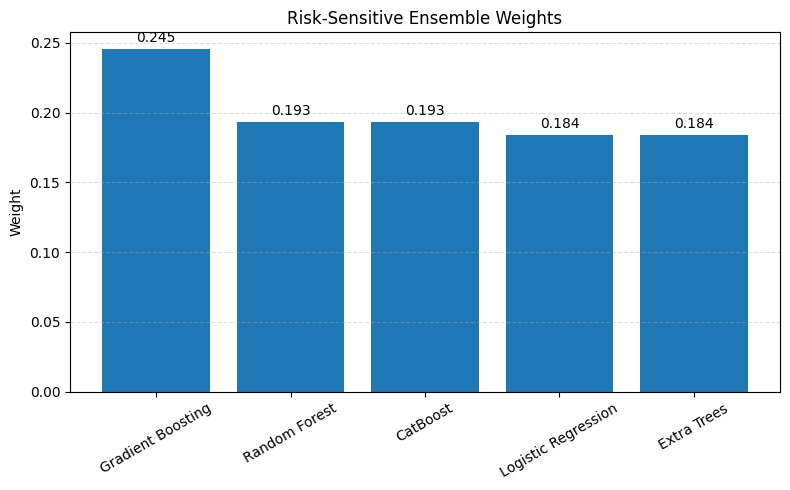

In [174]:
ensemble_weights_df = validation_results[
    ["Model", "Ensemble Weight"]
].copy()

ensemble_weights_df = ensemble_weights_df.sort_values(
    by="Ensemble Weight",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    ensemble_weights_df["Model"],
    ensemble_weights_df["Ensemble Weight"]
)

plt.title("Risk-Sensitive Ensemble Weights")
plt.ylabel("Weight")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("ensemble_weights.png", dpi=300)
plt.show()